# Hockey AI: How to Detect, Track, and Identify Hockey Players

This notebook adapts a basketball player tracking pipeline to hockey. We simplify the segmentation step by using YOLO segmentation instead of Segment Anything (SAM2).

## 1. Setup Environment and Dependencies

Install `ultralytics` for YOLO models, `supervision` for tracking and annotations, and other required utilities.

In [1]:
!pip install -q supervision ultralytics gdown easyocr
!pip install -q transformers num2words

In [2]:
from pathlib import Path
import os
import cv2
import numpy as np
from tqdm.notebook import tqdm
from IPython.display import Video

import supervision as sv
from ultralytics import YOLO

HOME = Path.cwd()
print("HOME:", HOME)

HOME: /home/vkretz/Programming/UQAC/DeepLearning/Projet


## 2. Source Videos and Team Rosters

We define the source video for hockey and a dictionary representing the team rosters.

In [3]:
SOURCE_VIDEO_DIRECTORY = HOME / "video"
SOURCE_VIDEO_DIRECTORY.mkdir(parents=True, exist_ok=True)

# Example video path (you'll need to provide your own or download one)
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "hockey" / "hockey_Maple_Leafs_vs_Canadiens_30s.mp4"

TEAM_ROSTERS = {
  "Montreal Canadiens": {
    "8": "Matheson",
    "11": "Gallagher",
    "13": "Caufield",
    "14": "Suzuki",
    "15": "Newhook",
    "17": "Anderson",
    "20": "Slafkovsky",
    "21": "Guhle",
    "24": "Danault",
    "28": "Dvorak",
    "35": "Montembeault",
    "40": "Armia",
    "42": "Engstrom",
    "45": "Carrier",
    "47": "Struble",
    "48": "Hutson",
    "51": "Heineman",
    "53": "Dobson",
    "55": "Pezzetta",
    "58": "Savard",
    "71": "Evans",
    "72": "Xhekaj",
    "75": "Dobes",
    "76": "Bolduc",
    "77": "Dach",
    "85": "Texier",
    "90": "Veleno",
    "91": "Kapanen",
    "92": "Laine",
    "93": "Demidov"
  },
  "Toronto Maple Leafs": {
    "2": "Benoit",
    "8": "Tanev",
    "11": "Domi",
    "18": "Lorentz",
    "19": "Jarnkrok",
    "22": "McCabe",
    "23": "Knies",
    "25": "Carlo",
    "26": "Quillan",
    "28": "Stecher",
    "29": "Groulx",
    "34": "Matthews",
    "41": "Stolarz",
    "43": "Haymes",
    "44": "Rielly",
    "51": "Myers",
    "53": "Cowan",
    "60": "Woll",
    "61": "Pezzetta",
    "63": "Maccelli",
    "70": "Akhtyamov",
    "76": "Villeneuve",
    "77": "Tverberg",
    "81": "Joshua",
    "88": "Nylander",
    "89": "Robertson",
    "91": "Tavares",
    "95": "Ekman-Larsson"
  }
}

TEAM_COLORS = {
    "Montreal Canadiens": "#AF1E2D", # Red
    "Toronto Maple Leafs": "#9DC1F0"  # White
}

## 3. Player Detection and Segmentation with YOLO

Instead of using RF-DETR + SAM2, we load a YOLO Segmentation model to detect players, referees, and the puck, and yield segmentation masks simultaneously.

In [4]:
# Path to your YOLO segmentation model (replace with a trained model path if available)
# e.g., HOME / "models" / "yolo26l-seg.pt"
YOLO_SEG_MODEL_PATH = HOME / "models" / "yolo26l-seg.pt"
OV_SEG_MODEL_PATH = HOME / "models" / "yolo26l-seg_int8_openvino_model"

# Initialize YOLO model
model = YOLO(
    (
        YOLO_SEG_MODEL_PATH
        if YOLO_SEG_MODEL_PATH.exists()
        else HOME / "models" / "yolo26n-seg.pt"
    ),
    task="segment",
)

if os.path.exists(OV_SEG_MODEL_PATH):
    model = YOLO(OV_SEG_MODEL_PATH, task="segment")
    print(f"Using OpenVINO optimized model from {OV_SEG_MODEL_PATH}")

PLAYER_CLASS_ID = 0  # Assuming 'person' is class 0 in COCO or your custom model

Using OpenVINO optimized model from /home/vkretz/Programming/UQAC/DeepLearning/Projet/models/yolo26l-seg_int8_openvino_model


Loading /home/vkretz/Programming/UQAC/DeepLearning/Projet/models/yolo26l-seg_int8_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...

0: 640x640 11 persons, 2 baseball bats, 151.9ms
Speed: 17.5ms preprocess, 151.9ms inference, 16.5ms postprocess per image at shape (1, 3, 640, 640)


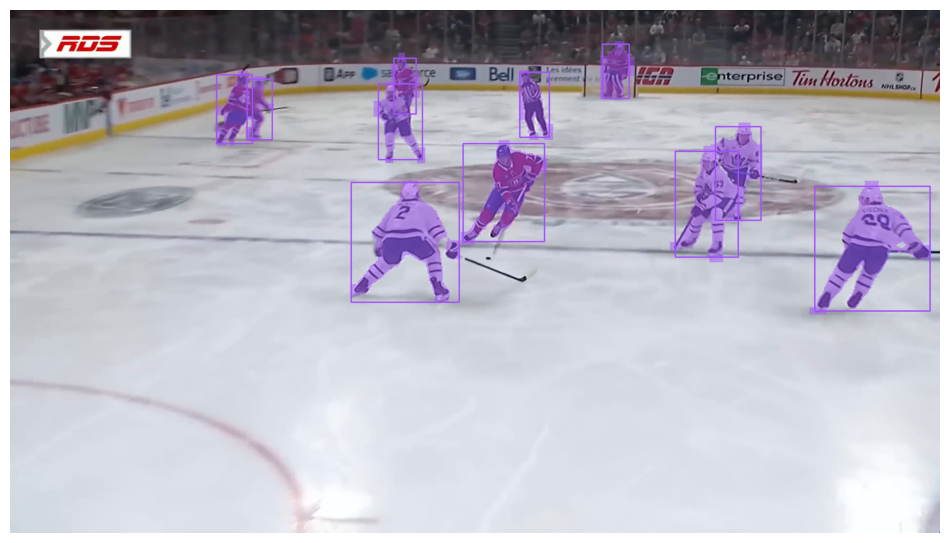

In [5]:
# Single frame detection and segmentation
if SOURCE_VIDEO_PATH.exists():
    frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
    frame = next(frame_generator)

    results = model.predict(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == PLAYER_CLASS_ID]

    mask_annotator = sv.MaskAnnotator(opacity=0.5)
    box_annotator = sv.BoxAnnotator(thickness=2)

    annotated_frame = frame.copy()
    annotated_frame = mask_annotator.annotate(
        scene=annotated_frame, detections=detections
    )
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame, detections=detections
    )

    sv.plot_image(annotated_frame)
else:
    print(f"Video {SOURCE_VIDEO_PATH} not found.")

## 4. Player Tracking with Supervision

Initialize a tracker using `supervision` to persist detections across frames.

In [6]:
tracker = sv.ByteTrack()

# Example tracking usage
if SOURCE_VIDEO_PATH.exists():
    frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
    frame = next(frame_generator)
    
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = detections[detections.class_id == PLAYER_CLASS_ID]
    
    # Update tracker
    detections = tracker.update_with_detections(detections)


0: 640x640 11 persons, 2 baseball bats, 70.6ms
Speed: 1.5ms preprocess, 70.6ms inference, 6.9ms postprocess per image at shape (1, 3, 640, 640)


## 5. Cluster Players into Teams

We extract player crops and use K-Means clustering (using color histograms) to group players into two teams based on jersey colors.

In [7]:
from sklearn.cluster import KMeans

def extract_color_histogram(image, mask=None, bins=(8, 8, 8)):
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Calculate histogram
    hist = cv2.calcHist([hsv], [0, 1, 2], mask, bins, [0, 180, 0, 256, 0, 256])
    cv2.normalize(hist, hist)
    return hist.flatten()

# Example classification over multiple crops
def cluster_teams(crops, masks=None, n_clusters=2):
    features = []
    for i, crop in enumerate(crops):
        mask = masks[i] if masks is not None else None
        # Convert mask to uint8 for cv2
        if mask is not None:
            mask = (mask * 255).astype(np.uint8)
        hist = extract_color_histogram(crop, mask)
        features.append(hist)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(features)
    return labels

## 6. Jersey Number OCR

Run an OCR model on cropped jersey regions. We use Intersection over Union (IoU) to match numbers to specific player masks.

In [8]:
import easyocr

# On initialise le lecteur en anglais (seule langue requise pour des chiffres), avec le GPU si disponible
reader = easyocr.Reader(['en'], gpu=True)

def perform_ocr(image_crop):
    """
    Rogne l'image au torse du joueur (si on s'appuie sur YOLO) ou au casque 
    et tente une lecture optique uniquement des chiffres '0123456789'.
    """
    # 'allowlist' force la lecture de chiffres uniquement
    result = reader.readtext(image_crop, allowlist='0123456789', detail=0)
    
    # readtext retourne une liste de chaînes trouvées. Soit on prend le premier, soit aucun.
    if len(result) > 0:
        # EasyOCR peut renvoyer '88 1' s'il y a des numéros sur casque et buste
        # mais de manière générale un seul numéro sera rendu
        return result[0]
    return None

## 7. Player Recognition Pipeline

Combine tracking IDs, team clustering results, and OCR outputs over consecutive frames to validate and annotate each player with their name and number.

In [9]:
# Validateur personnalisé requérant des prédictions OCR constantes sur N trames pour un joueur
class ConsecutiveValueTracker:
    def __init__(self, n_consecutive=3):
        self.n_consecutive = n_consecutive
        self.history = {} # Clé: Tracker ID, Valeur: list[predictions OCR]
        self.validated = {} # Clé: Tracker ID, Valeur: prediction finale vérifiée
        
    def update(self, tracker_ids, values):
        """Met à jour l'historique d'OCR pour les tracker_ids donnés."""
        for tid, val in zip(tracker_ids, values):
            # On ignore si l'OCR n'a rien vu sur cette frame
            if val is None or val == "":
                continue 
            
            if tid not in self.history:
                self.history[tid] = []
                
            self.history[tid].append(val)
            # Ne garder que les 'N' derniers éléments lus
            self.history[tid] = self.history[tid][-self.n_consecutive:]
            
            # Si nous avons accumulé N lectures consécutives, 
            # et qu'elles sont TOUTES identiques, on valide le rendu
            if len(self.history[tid]) == self.n_consecutive and len(set(self.history[tid])) == 1:
                self.validated[tid] = val
                
    def get_validated(self, tracker_ids):
        """Retourne les valeurs vérifiées pour chaque tracker IDs (None si pas encore validé)."""
        return [self.validated.get(tid, None) for tid in tracker_ids]

## 8. Hockey Rink Keypoint Detection

Detect specific rink landmarks (e.g., faceoff circles, blue lines).

Using OpenVINO optimized model from /home/vkretz/Programming/UQAC/DeepLearning/Projet/models/HockeyAI_model_weight_openvino_model
Loading /home/vkretz/Programming/UQAC/DeepLearning/Projet/models/HockeyAI_model_weight_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...

0: 1280x1280 2 faceoffs, 1 goalie, 9 players, 2 pucks, 1 referee, 389.4ms
Speed: 8.4ms preprocess, 389.4ms inference, 1.2ms postprocess per image at shape (1, 3, 1280, 1280)
Points détectés : ['faceoff' 'faceoff']


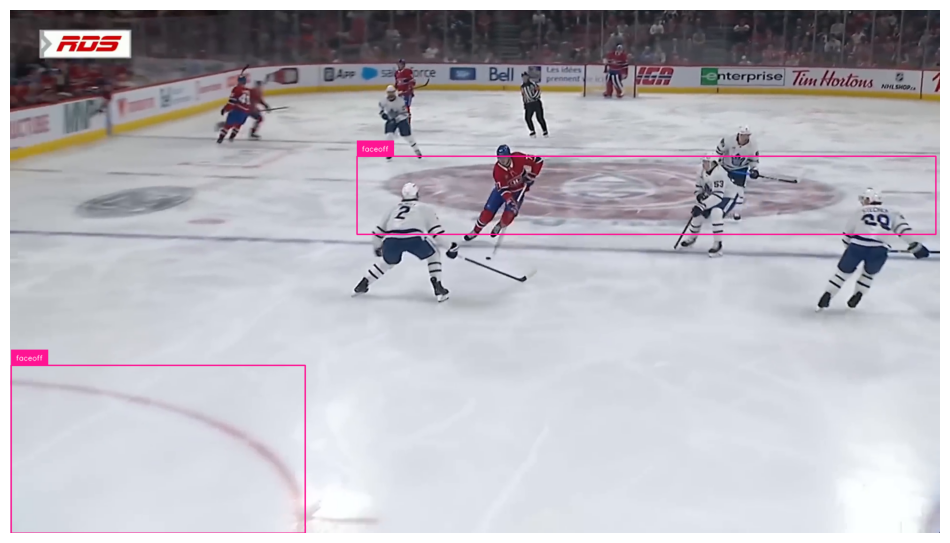

In [10]:
KEYPOINT_MODEL_PATH = HOME / "models" / "HockeyAI_model_weight.pt"
OV_KEYPOINT_MODEL_PATH = HOME / "models" / "HockeyAI_model_weight_openvino_model"
keypoint_model = YOLO(KEYPOINT_MODEL_PATH, task="detect")

if os.path.exists(OV_KEYPOINT_MODEL_PATH):
    keypoint_model = YOLO(OV_KEYPOINT_MODEL_PATH, task="detect")
    print(f"Using OpenVINO optimized model from {OV_KEYPOINT_MODEL_PATH}")

# Les classes que l'on souhaite conserver pour cartographier la patinoire
TARGET_LANDMARKS = ["centriod", "faceoff", "goal"]

if SOURCE_VIDEO_PATH.exists():
    frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
    frame = next(frame_generator)
    
    results = keypoint_model.predict(frame)[0]
    kp_detections = sv.Detections.from_ultralytics(results)
    
    # Obtenir la liste des noms de classes détectées
    class_names = np.array([keypoint_model.names[cid] for cid in kp_detections.class_id])
    
    # Créer un masque pour filtrer et conserver uniquement les points clés du terrain
    mask = np.isin(class_names, TARGET_LANDMARKS)
    landmark_detections = kp_detections[mask]
    
    # Récupérer les noms des landmarks filtrés pour l'affichage
    landmark_labels = class_names[mask]
    print(f"Points détectés : {landmark_labels}")
    
    # Visualisation des repères sur l'image
    box_annotator = sv.BoxAnnotator(thickness=2, color=sv.Color.from_hex("#FF1493"))
    label_annotator = sv.LabelAnnotator(text_scale=0.5, color=sv.Color.from_hex("#FF1493"))
    
    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame, detections=landmark_detections
    )
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame, detections=landmark_detections, labels=landmark_labels
    )
    
    sv.plot_image(annotated_frame)

## 9. Map Positions to Rink Coordinates

We calculate a homography matrix using the detected keypoints and transform the players' bottom-center coordinates from the camera view to a 2D top-down rink representation.

In [11]:
# Dimensions d'une patinoire de la LNH : 200 pieds x 85 pieds
# L'origine (0,0) est située dans le coin supérieur gauche.

RINK_DEFAULT_2D = {
    "Center Ice": np.array([100.0, 42.5]),
    "Goal Frame Left": np.array([11.0, 42.5]),   
    "Goal Frame Right": np.array([189.0, 42.5]), 
    "Faceoff Dot N Z1": np.array([76.0, 20.5]),  
    "Faceoff Dot N Z2": np.array([76.0, 64.5]),  
    "Faceoff Dot N Z3": np.array([124.0, 20.5]), 
    "Faceoff Dot N Z4": np.array([124.0, 64.5]), 
    "Faceoff Dot Def Left Top": np.array([31.0, 20.5]),
    "Faceoff Dot Def Left Bot": np.array([31.0, 64.5]),
    "Faceoff Dot Def Right Top": np.array([169.0, 20.5]),
    "Faceoff Dot Def Right Bot": np.array([169.0, 64.5]),
}

def draw_hockey_rink_2d(scale=3):
    """
    Dessine une vue 2D "top-down" d'une patinoire de hockey (200x85)
    L'image renvoyée peut être incrustée comme une "mini-map".
    """
    w, h = int(200 * scale), int(85 * scale)
    rink_img = np.ones((h, w, 3), dtype=np.uint8) * 250 # Fond presque blanc
    
    # Ligne centrale (rouge)
    cv2.line(rink_img, (int(100*scale), 0), (int(100*scale), h), (0, 0, 255), 2)
    # Lignes bleues
    cv2.line(rink_img, (int(75*scale), 0), (int(75*scale), h), (255, 0, 0), 2)
    cv2.line(rink_img, (int(125*scale), 0), (int(125*scale), h), (255, 0, 0), 2)
    # Lignes de buts (rouge)
    cv2.line(rink_img, (int(11*scale), 0), (int(11*scale), h), (0, 0, 255), 1)
    cv2.line(rink_img, (int(189*scale), 0), (int(189*scale), h), (0, 0, 255), 1)
    
    # Cercle central (bleu)
    cv2.circle(rink_img, (int(100*scale), int(42.5*scale)), int(15*scale), (255, 0, 0), 2)
    
    # Cercles de faceoff des zones défensives (rouge)
    for x in [31, 169]:
        for y in [20.5, 64.5]:
            cv2.circle(rink_img, (int(x*scale), int(y*scale)), int(15*scale), (0, 0, 255), 1)
            cv2.circle(rink_img, (int(x*scale), int(y*scale)), int(1*scale), (0, 0, 255), -1)
            
    # Faceoff dots Zone Neutre (rouge)
    for x in [76, 124]:
        for y in [20.5, 64.5]:
            cv2.circle(rink_img, (int(x*scale), int(y*scale)), int(1*scale), (0, 0, 255), -1)
            
    # Bordure patinoire
    cv2.rectangle(rink_img, (0, 0), (w, h), (0, 0, 0), 3)
    
    return rink_img

def draw_points_on_rink(rink_img, points, color, scale=3, radius=4):
    """Dessine des points projetés sur la patinoire."""
    img = rink_img.copy()
    if points is None or len(points) == 0:
        return img
    for pt in points:
        x, y = int(pt[0]*scale), int(pt[1]*scale)
        # On contraint l'affichage pour éviter de crasher si la projection déborde
        x = max(0, min(x, img.shape[1]-1))
        y = max(0, min(y, img.shape[0]-1))
        cv2.circle(img, (x, y), radius, color, -1)
    return img

## 10 Pipeline glabal

In [12]:
from datetime import datetime

TARGET_VIDEO_PATH = HOME / "video" / "hockey" / "out" / f"output_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.mp4"

class ViewTransformer:
    """
    Remplacement personnalisé de sv.ViewTransformer, qui n'est pas toujours disponible
    selon la version de 'supervision' installée. Wrap simple autour de cv2.findHomography.
    """
    def __init__(self, source: np.ndarray, target: np.ndarray):
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m, _ = cv2.findHomography(source, target)

    def transform_points(self, points: np.ndarray) -> np.ndarray:
        if self.m is None or len(points) == 0:
            return points
        reshaped_points = points.reshape(-1, 1, 2).astype(np.float32)
        transformed_points = cv2.perspectiveTransform(reshaped_points, self.m)
        return transformed_points.reshape(-1, 2)

def map_generic_keypoints_to_specific(landmark_detections, model_names, img_width):
    """
    Heuristique spatiale pour assigner des labels génériques ('faceoff', 'goal', 'centroid')
    aux points précis de la patinoire RINK_DEFAULT_2D.
    """
    centroids, goals, faceoffs = [], [], []
    for xyxy, cid in zip(landmark_detections.xyxy, landmark_detections.class_id):
        c_name = model_names[cid].lower()
        cx, cy = (xyxy[0] + xyxy[2]) / 2.0, (xyxy[1] + xyxy[3]) / 2.0
        
        if "centri" in c_name: # Handle 'centroid' or 'centriod' typos
            centroids.append((cx, cy))
        elif "goal" in c_name:
            goals.append((cx, cy))
        elif "faceoff" in c_name:
            faceoffs.append((cx, cy))
            
    assigned_pts = {}
    center_x = centroids[0][0] if centroids else img_width / 2.0
    
    if centroids:
        assigned_pts["Center Ice"] = centroids[0]
        
    for gx, gy in goals:
        if gx < center_x:
            assigned_pts["Goal Frame Left"] = (gx, gy)
        else:
            assigned_pts["Goal Frame Right"] = (gx, gy)
            
    # Tri des faceoffs : Gauche/Droite, puis Haut/Bas
    left_fs = sorted([p for p in faceoffs if p[0] < center_x], key=lambda x: x[1])
    right_fs = sorted([p for p in faceoffs if p[0] >= center_x], key=lambda x: x[1])
    
    has_left_goal = "Goal Frame Left" in assigned_pts
    has_right_goal = "Goal Frame Right" in assigned_pts
    
    # Assigner Faceoffs Gauche (Zone neutre ou Zone défensive selon la présence du but gauche)
    for i, p in enumerate(left_fs[:2]):
        label = "Faceoff Dot Def Left Top" if has_left_goal and i==0 else \
                "Faceoff Dot Def Left Bot" if has_left_goal and i==1 else \
                "Faceoff Dot N Z1" if i==0 else "Faceoff Dot N Z2"
        assigned_pts[label] = p
        
    # Assigner Faceoffs Droite (Zone neutre ou défensive)
    for i, p in enumerate(right_fs[:2]):
        label = "Faceoff Dot Def Right Top" if has_right_goal and i==0 else \
                "Faceoff Dot Def Right Bot" if has_right_goal and i==1 else \
                "Faceoff Dot N Z3" if i==0 else "Faceoff Dot N Z4"
        assigned_pts[label] = p
        
    return assigned_pts


def setup_global_pipeline(video_path, yolo_seg_model, yolo_kp_model, ocr_reader):
    """
    Rassemble les 10 sections du notebook dans un seul traitement en séquence (boucle vidéo).
    """
    sv_tracker_players = sv.ByteTrack()
    sv_tracker_puck = sv.ByteTrack() 
    valeur_ocr_tracker = ConsecutiveValueTracker(n_consecutive=3)
    
    PLAYER_CLASS_ID = next((k for k, v in yolo_seg_model.names.items() if v.lower() in ["person", "player"]), 0)
    PUCK_CLASS_ID = next((k for k, v in yolo_kp_model.names.items() if v.lower() == "puck"), -1) # Default to -1 if missing
    
    box_annotator = sv.BoxAnnotator(thickness=2)
    puck_annotator = sv.BoxAnnotator(thickness=4, color=sv.Color.from_hex("#000000"))
    label_annotator = sv.LabelAnnotator(text_scale=0.6, color=sv.Color.BLACK)
    
    last_transformer = None
    last_puck_detections = None # Cache pour la rondelle
    SCALE_MAP = 3 
    OVERLAY_OPACITY = 0.8
    
    # OPTIMISATION 1 : Pré-calculer le fond de la carte 2D une seule fois
    base_rink_2d = draw_hockey_rink_2d(scale=SCALE_MAP)
    
    video_info = sv.VideoInfo.from_video_path(video_path)
    frame_generator = sv.get_video_frames_generator(video_path)

    with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
        for i, frame in enumerate(tqdm(frame_generator, total=video_info.total_frames)):
            
            # --- 1. DÉTECTION GÉNÉRALE (YOLO_SEG) ---
            results_seg = yolo_seg_model.predict(frame, verbose=False, imgsz=640)[0] 
            detections_all = sv.Detections.from_ultralytics(results_seg)
            detections_players = detections_all[detections_all.class_id == PLAYER_CLASS_ID]
            
            # --- 2. TRACKING ---
            detections_players = sv_tracker_players.update_with_detections(detections_players)
            
            # --- 3. LECTURE OCR ---
            if i % 5 == 0 and len(detections_players) > 0:
                xyxys = detections_players.xyxy
                tids = detections_players.tracker_id
                ocr_values = []
                for tid, xyxy in zip(tids, xyxys):
                    if tid in valeur_ocr_tracker.validated:
                        ocr_values.append(valeur_ocr_tracker.validated[tid])
                    else:
                        x1, y1, x2, y2 = map(int, xyxy)
                        crop = frame[max(0,y1):min(video_info.height,y2), max(0,x1):min(video_info.width,x2)]
                        ocr_values.append(perform_ocr(crop) if crop.size > 0 else None)
                valeur_ocr_tracker.update(tids, ocr_values)
                
            # --- 4. LABELS ---
            labels = []
            valid_ocrs = valeur_ocr_tracker.get_validated(detections_players.tracker_id)
            for tid, valid_ocr in zip(detections_players.tracker_id, valid_ocrs):
                labels.append(f"#{valid_ocr}" if valid_ocr is not None else f"Joueur {tid}")
                    
            # --- 5. POINTS CLÉS ET PUCK (YOLO_KP) ---
            if i % 3 == 0:
                results_kp = yolo_kp_model.predict(frame, verbose=False, imgsz=1280)[0]
                kp_detections = sv.Detections.from_ultralytics(results_kp)
                
                # Check puck detection safely
                if PUCK_CLASS_ID != -1:
                    detections_puck = kp_detections[kp_detections.class_id == PUCK_CLASS_ID]
                else:
                    detections_puck = sv.Detections.empty()
                    
                try:
                    detections_puck = sv_tracker_puck.update_with_detections(detections_puck)
                    last_puck_detections = detections_puck
                except: 
                    last_puck_detections = sv.Detections.empty()
                
                mask_kp = np.isin([yolo_kp_model.names[cid] for cid in kp_detections.class_id], TARGET_LANDMARKS)
                landmark_detections = kp_detections[mask_kp]
                
                # --- 6. HOMOGRAPHIE AVEC HEURISTIQUE SPATIALE ---
                if len(landmark_detections) >= 4:
                    assigned_points = map_generic_keypoints_to_specific(
                        landmark_detections, 
                        yolo_kp_model.names, 
                        video_info.width
                    )
                    
                    src_points, dst_points = [], []
                    for label, pt in assigned_points.items():
                        if label in RINK_DEFAULT_2D:
                            src_points.append(pt)
                            dst_points.append(RINK_DEFAULT_2D[label])
                    
                    if len(src_points) >= 4:
                        # Utilisation de la nouvelle classe ViewTransformer locale
                        new_transformer = ViewTransformer(
                            source=np.array(src_points, dtype=np.float32),
                            target=np.array(dst_points, dtype=np.float32)
                        )
                        try:
                            _ = new_transformer.transform_points(points=np.array([[0.0, 0.0]]))
                            last_transformer = new_transformer
                        except: pass
            else:
                detections_puck = last_puck_detections if last_puck_detections is not None else sv.Detections.empty()
                
            # --- 7. RENDU MINI-MAP ET OVERLAY ---
            rink_2d = base_rink_2d.copy()
            
            if last_transformer is not None:
                if len(detections_players) > 0:
                    player_bottoms = detections_players.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)
                    rink_xy_players = last_transformer.transform_points(points=player_bottoms)
                    rink_2d = draw_points_on_rink(rink_2d, rink_xy_players, color=(255, 0, 0), scale=SCALE_MAP, radius=5) 

                if len(detections_puck) > 0: 
                    puck_center = detections_puck.get_anchors_coordinates(anchor=sv.Position.CENTER)
                    rink_xy_puck = last_transformer.transform_points(points=puck_center)
                    rink_2d = draw_points_on_rink(rink_2d, rink_xy_puck, color=(0, 0, 0), scale=SCALE_MAP, radius=8)
                
            annotated_frame = box_annotator.annotate(scene=frame.copy(), detections=detections_players)
            annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections_players, labels=labels)
            
            if len(detections_puck) > 0:
                annotated_frame = puck_annotator.annotate(scene=annotated_frame, detections=detections_puck)
            
            r_h, r_w = rink_2d.shape[:2]
            margin = 20
            y_start, x_start = video_info.height - r_h - margin, video_info.width - r_w - margin
            
            if y_start > 0 and x_start > 0:
                overlay = annotated_frame[y_start:y_start+r_h, x_start:x_start+r_w].copy()
                cv2.addWeighted(rink_2d, OVERLAY_OPACITY, overlay, 1 - OVERLAY_OPACITY, 0, overlay)
                annotated_frame[y_start:y_start+r_h, x_start:x_start+r_w] = overlay
            
            sink.write_frame(annotated_frame)
            
    print(f"Pipeline terminé. Résultat sauvegardé dans {TARGET_VIDEO_PATH}")

In [13]:
# Lancement (Commenté pour ne pas exploser le notebook immédiatement)
setup_global_pipeline(SOURCE_VIDEO_PATH, model, keypoint_model, reader)

  0%|          | 0/2020 [00:00<?, ?it/s]

Pipeline terminé. Résultat sauvegardé dans /home/vkretz/Programming/UQAC/DeepLearning/Projet/video/hockey/out/output_pipeline_20260410_135430.mp4
